Given a distribution $P(x,y)$ in the (complex) plane.
We want to calculate the integral  
$$
\rho(u) = \int dxdy \, P(x, y) \delta(u-|K(x,y)|)
$$
where K is some function of x and y. We estimate $P(x,y)$ via a histogram $H(x,y)$ and approximate it via  
$$
\rho(u) \approx \sum_{x,y} \, H(x,y) \delta_{u, |K(x,y)|}
$$
where 
$$
\delta_{u, |K(x,y)|} = \begin{cases} 
      1 & u = |K(x,y)| \\
      0 & \text{else} \\
   \end{cases}
$$
Loosly speaking, the approximation counts the number of points in the dataset that satisfy $u = |K(x,y)|$ for given $u$.


Given a dataset $D = \{(x_i, y_i)\}_{i=1}^{K}$ consisting of $K$ pairs. Every pair represents a configuration of the complex scalar.  

- If necessary, remove datapoints with $x^2+y^2>C$ ($\le \infty$)
- Choose the number of bins in the plane and create a histogram $H_{N \times N}$ of $D$. It is a matrix of size $N \times N$,  
it's entries count the number of pairs $(x_i, y_i)$ in each bin.
- Slice the plane $[x_{min}, x_{max}] \times [y_{min}, y_{max}]$ into a $N \times N$ grid and calculate $K$ on this grid.
- Define a new dataset $A$. It consists of values in $u$ with multiplicity according to $H$. 
- Choose the number of bins in $u$. The histogram of $A$ counts how many pairs for a given $u$ are in each bin. This is our drift histogram

We can use numpy to to study the drift histogram by calculating a histogram of K on the $N \times N$ grid and passing $H_{N \times N}$ as *weights*.  
To check this, we study a special case. If $K(x,y)$ is rotational symmetric, we stand a chance to get a analytical result for $\rho(u)$

In the first example, assume 
$$
K(x, y) = \sqrt{x^2+y^2}
$$
and a uniform distribution in a circle $C$ with radius $R$
$$
P(x, y) = \frac{1}{R^2 \pi}
$$
$\rho$ reduces to
$$
\rho(u) = \int_C dx dy \, \frac{1}{R^2 \pi} \delta(u-\sqrt{x^2+y^2}) = \int_{0}^{2 \pi} \int_{0}^{R}rdrd\phi \, \frac{1}{R^2 \pi} \delta(u-r) = \frac{2u}{C^2}
$$

/tmp/ipykernel_205941/16757872.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[2].set_xlim(0, C)


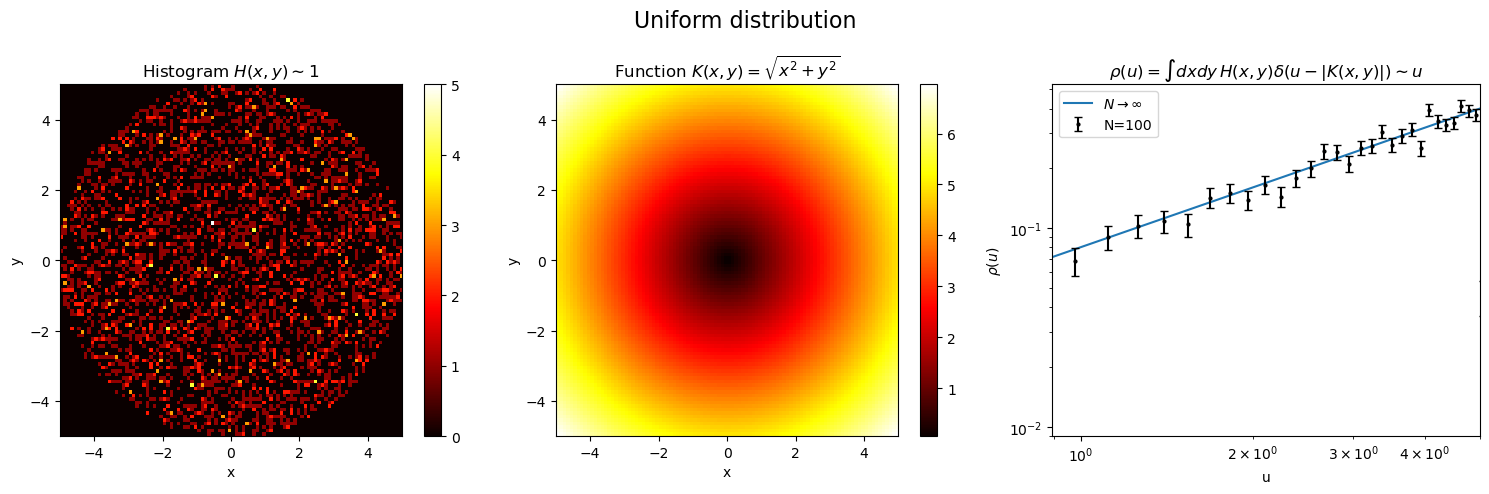

In [4]:
import numpy as np
import matplotlib.pyplot as plt

K_samples = int(5e3)  # Number of (x, y) pairs
N = int(1e2)  # Grid size
U_bins_num = int(5e1)

# Generate synthetic dataset D = {(x_i, y_i)}
C = 5
x_data = np.random.uniform(-C, C, K_samples)
y_data = np.random.uniform(-C, C, K_samples)

# Filter out points where x^2 + y^2 > C
mask = x_data**2 + y_data**2 <C**2
x_data, y_data = x_data[mask], y_data[mask]

# Create a histogram of the data (H(x, y))
x_bins = np.linspace(-C, C, N+1)
y_bins = np.linspace(-C, C, N+1)
hist, x_edges, y_edges = np.histogram2d(x_data, y_data, bins=N)

# Compute U on the grid
X_centers = (x_edges[:-1] + x_edges[1:]) / 2
Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
X_grid, Y_grid = np.meshgrid(X_centers, Y_centers, indexing='ij')

U_values = np.sqrt(X_grid**2 + Y_grid**2)
U_min, U_max = U_values.min(), U_values.max()

U_bins = np.linspace(U_min, U_max, U_bins_num)
U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
rho_u = np.histogram(U_values.flatten(), bins = U_bins, weights = hist.flatten(), density=True)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram H(x,y)
c = axes[0].imshow(hist.T, origin='lower', extent=[-C, C, -C, C], aspect='auto', cmap='hot')
fig.colorbar(c, ax=axes[0])
axes[0].set_title(r"Histogram $H(x,y) \sim 1$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Function K(x,y) heatmap
c = axes[1].imshow(U_values.T, origin='lower', extent=[-C, C, -C, C], aspect='auto', cmap='hot')
fig.colorbar(c, ax=axes[1])
axes[1].set_title(r"Function $K(x,y) = \sqrt{x^2 + y^2}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Histogram rho(u)
axes[2].plot([0, C], [0, 2*C/C**2], label =r"$N \to \infty$")

axes[2].set_title(r"$\rho(u)=\int dx dy \, H(x,y) \delta(u-|K(x,y)|) \sim u$")
axes[2].set_xlabel("u")
axes[2].set_ylabel(r"$\rho(u)$")
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlim(0, C)
counts, U_edges = np.histogram(U_values.flatten(), bins=U_bins, weights=hist.flatten(), density=False)

# Standard error assuming Poisson statistics
rho_u_error = np.sqrt(counts) / (np.sum(hist) * np.diff(U_bins))
axes[2].errorbar(U_centers, rho_u[0], yerr=rho_u_error, fmt='o', color='black', markersize=2, capsize=3, label=f"N={N}")
axes[2].legend()

fig.suptitle("Uniform distribution", fontsize=16)
fig.tight_layout()

Now assume 
$$
K(x, y) = \sqrt{x^2+y^2}
$$
and a normal distribution in a the plane
$$
P(x, y) = \frac{1}{2\pi}e^{-\frac{1}{2}(x^2+y^2)}
$$
$\rho$ reduces to
$$
\rho(u) = \int_{\mathbb{R}^2} dx dy \, \frac{1}{2 \pi} e^{-\frac{1}{2}(x^2+y^2)}\delta(u-\sqrt{x^2+y^2}) = \int_{0}^{2 \pi} \int_{0}^{\infty}rdrd\phi \, \frac{1}{2 \pi} e^{-\frac{1}{2}r^2}\delta(u-r) = u e^{-\frac{1}{2}u^2}
$$

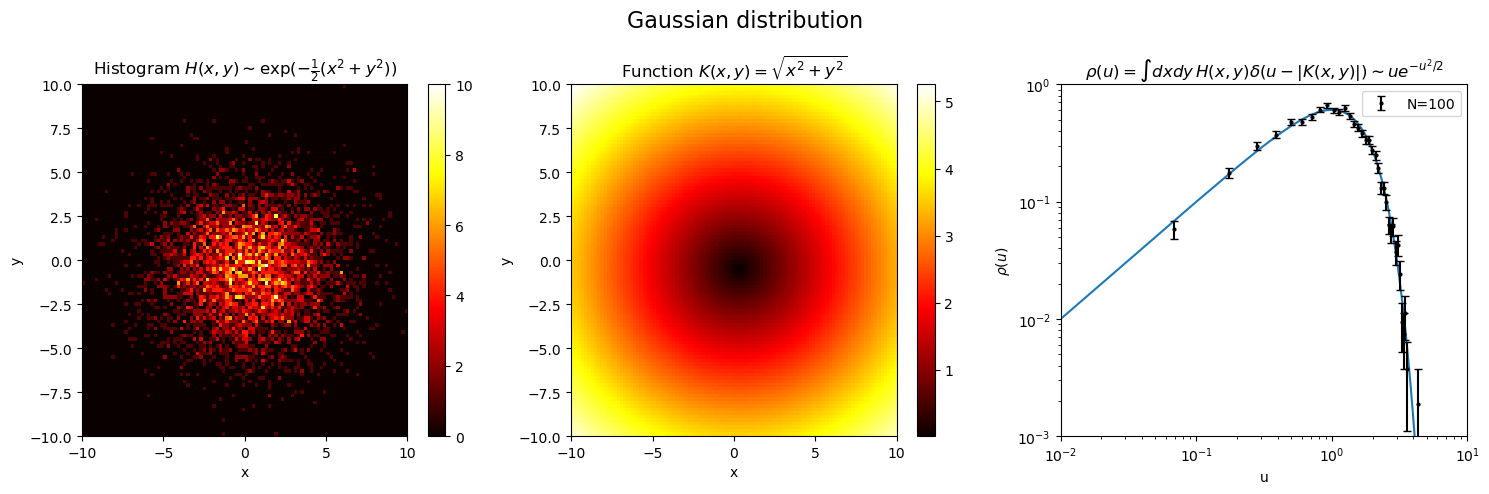

In [6]:
import numpy as np
import matplotlib.pyplot as plt

K_samples = int(5e3)  # Number of (x, y) pairs
N = int(1e2)  # Grid size
U_bins_num = int(5e1)

# Generate synthetic dataset D = {(x_i, y_i)}
C = 10
x_data = np.random.normal(0,1, K_samples)
y_data = np.random.normal(0,1, K_samples)


# Filter out points where x^2 + y^2 > C
mask = x_data**2 + y_data**2 <C**2
x_data, y_data = x_data[mask], y_data[mask]

# Create a histogram of the data (H(x, y))
x_bins = np.linspace(-C, C, N+1)
y_bins = np.linspace(-C, C, N+1)
hist, x_edges, y_edges = np.histogram2d(x_data, y_data, bins=N)

# Compute U on the grid
X_centers = (x_edges[:-1] + x_edges[1:]) / 2
Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
X_grid, Y_grid = np.meshgrid(X_centers, Y_centers, indexing='ij')

U_values = np.sqrt(X_grid**2 + Y_grid**2)
U_min, U_max = U_values.min(), U_values.max()

U_bins = np.linspace(U_min, U_max, U_bins_num)
U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
rho_u = np.histogram(U_values.flatten(), bins = U_bins, weights = hist.flatten(), density=True)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram H(x,y)
c = axes[0].imshow(hist.T, origin='lower', extent=[-C, C, -C, C], aspect='auto', cmap='hot')
fig.colorbar(c, ax=axes[0])
axes[0].set_title(r"Histogram $H(x,y) \sim \exp(-\frac{1}{2}(x^2+y^2))$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Function K(x,y) heatmap
c = axes[1].imshow(U_values.T, origin='lower', extent=[-C, C, -C, C], aspect='auto', cmap='hot')
fig.colorbar(c, ax=axes[1])
axes[1].set_title(r"Function $K(x,y) = \sqrt{x^2 + y^2}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Histogram rho(u)
A = np.repeat(U_values.flatten(), hist.flatten().astype(int))
A_hist, _ = np.histogram(A.T, bins = U_bins)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title(r"$\rho(u)=\int dx dy \, H(x,y) \delta(u-|K(x,y)|) \sim u e^{-u^2/2}$")
axes[2].set_xlabel("u")
axes[2].set_ylabel(r"$\rho(u)$")

counts, U_edges = np.histogram(U_values.flatten(), bins=U_bins, weights=hist.flatten(), density=False)
x = np.linspace(0, 10, 100)
axes[2].plot(x,x*np.exp(-1/2*x**2))

# Standard error assuming Poisson statistics
rho_u_error = np.sqrt(counts) / (np.sum(hist) * np.diff(U_bins))
axes[2].errorbar(U_centers, rho_u[0], yerr=rho_u_error, fmt='o', color='black', markersize=2, capsize=3, label=f"N={N}")
axes[2].set_xlim(0.01, C)
axes[2].set_ylim(1e-3,1)

axes[2].legend()

fig.suptitle("Gaussian distribution", fontsize=16)
fig.tight_layout()
